<a href="https://colab.research.google.com/github/roshika1235/Data_Analysis_Tasks/blob/main/DIABETES_DETECTION_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DIABETES DETECTION USING SVC

## IMPORT ALL NECESSARY LIBRARIES

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

## EXPLORE THE DATASET

In [41]:
data=load_diabetes()
# print(data.DESCR)
df=pd.DataFrame(data.data,columns=data.feature_names)
df["diabetes"]=data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,diabetes
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [42]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,diabetes
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [43]:
def diabetes_cat(num):
  if num>=126:
    return 1
  else:
    return 0
df['diabetes']=df['diabetes'].apply(diabetes_cat)


## EDA AND DATA VISUALIAZATION

<Axes: xlabel='diabetes', ylabel='Count'>

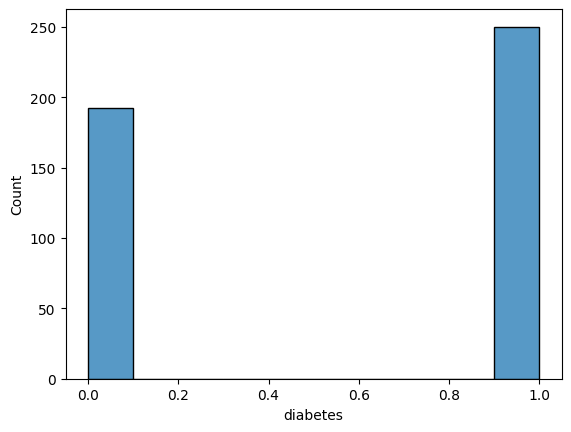

In [44]:
df['diabetes'].value_counts()
sns.histplot(df['diabetes'])

## SHOWS HOW MANY ARE SUFFERING FROM DIABETES

<Axes: xlabel='age', ylabel='Count'>

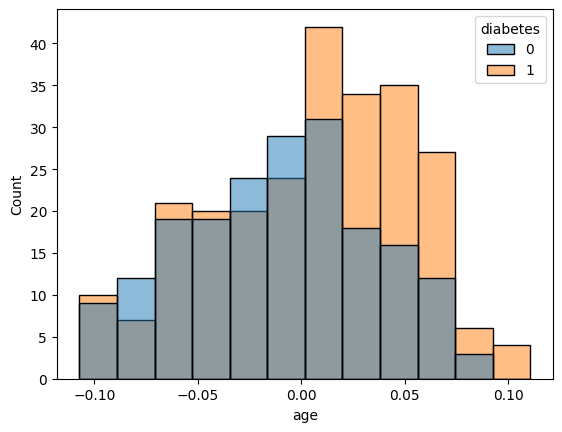

In [45]:
sns.histplot(x='age',data=df,hue='diabetes')

## WHICH AGE GROUP IS HAVING DIABETES MOST

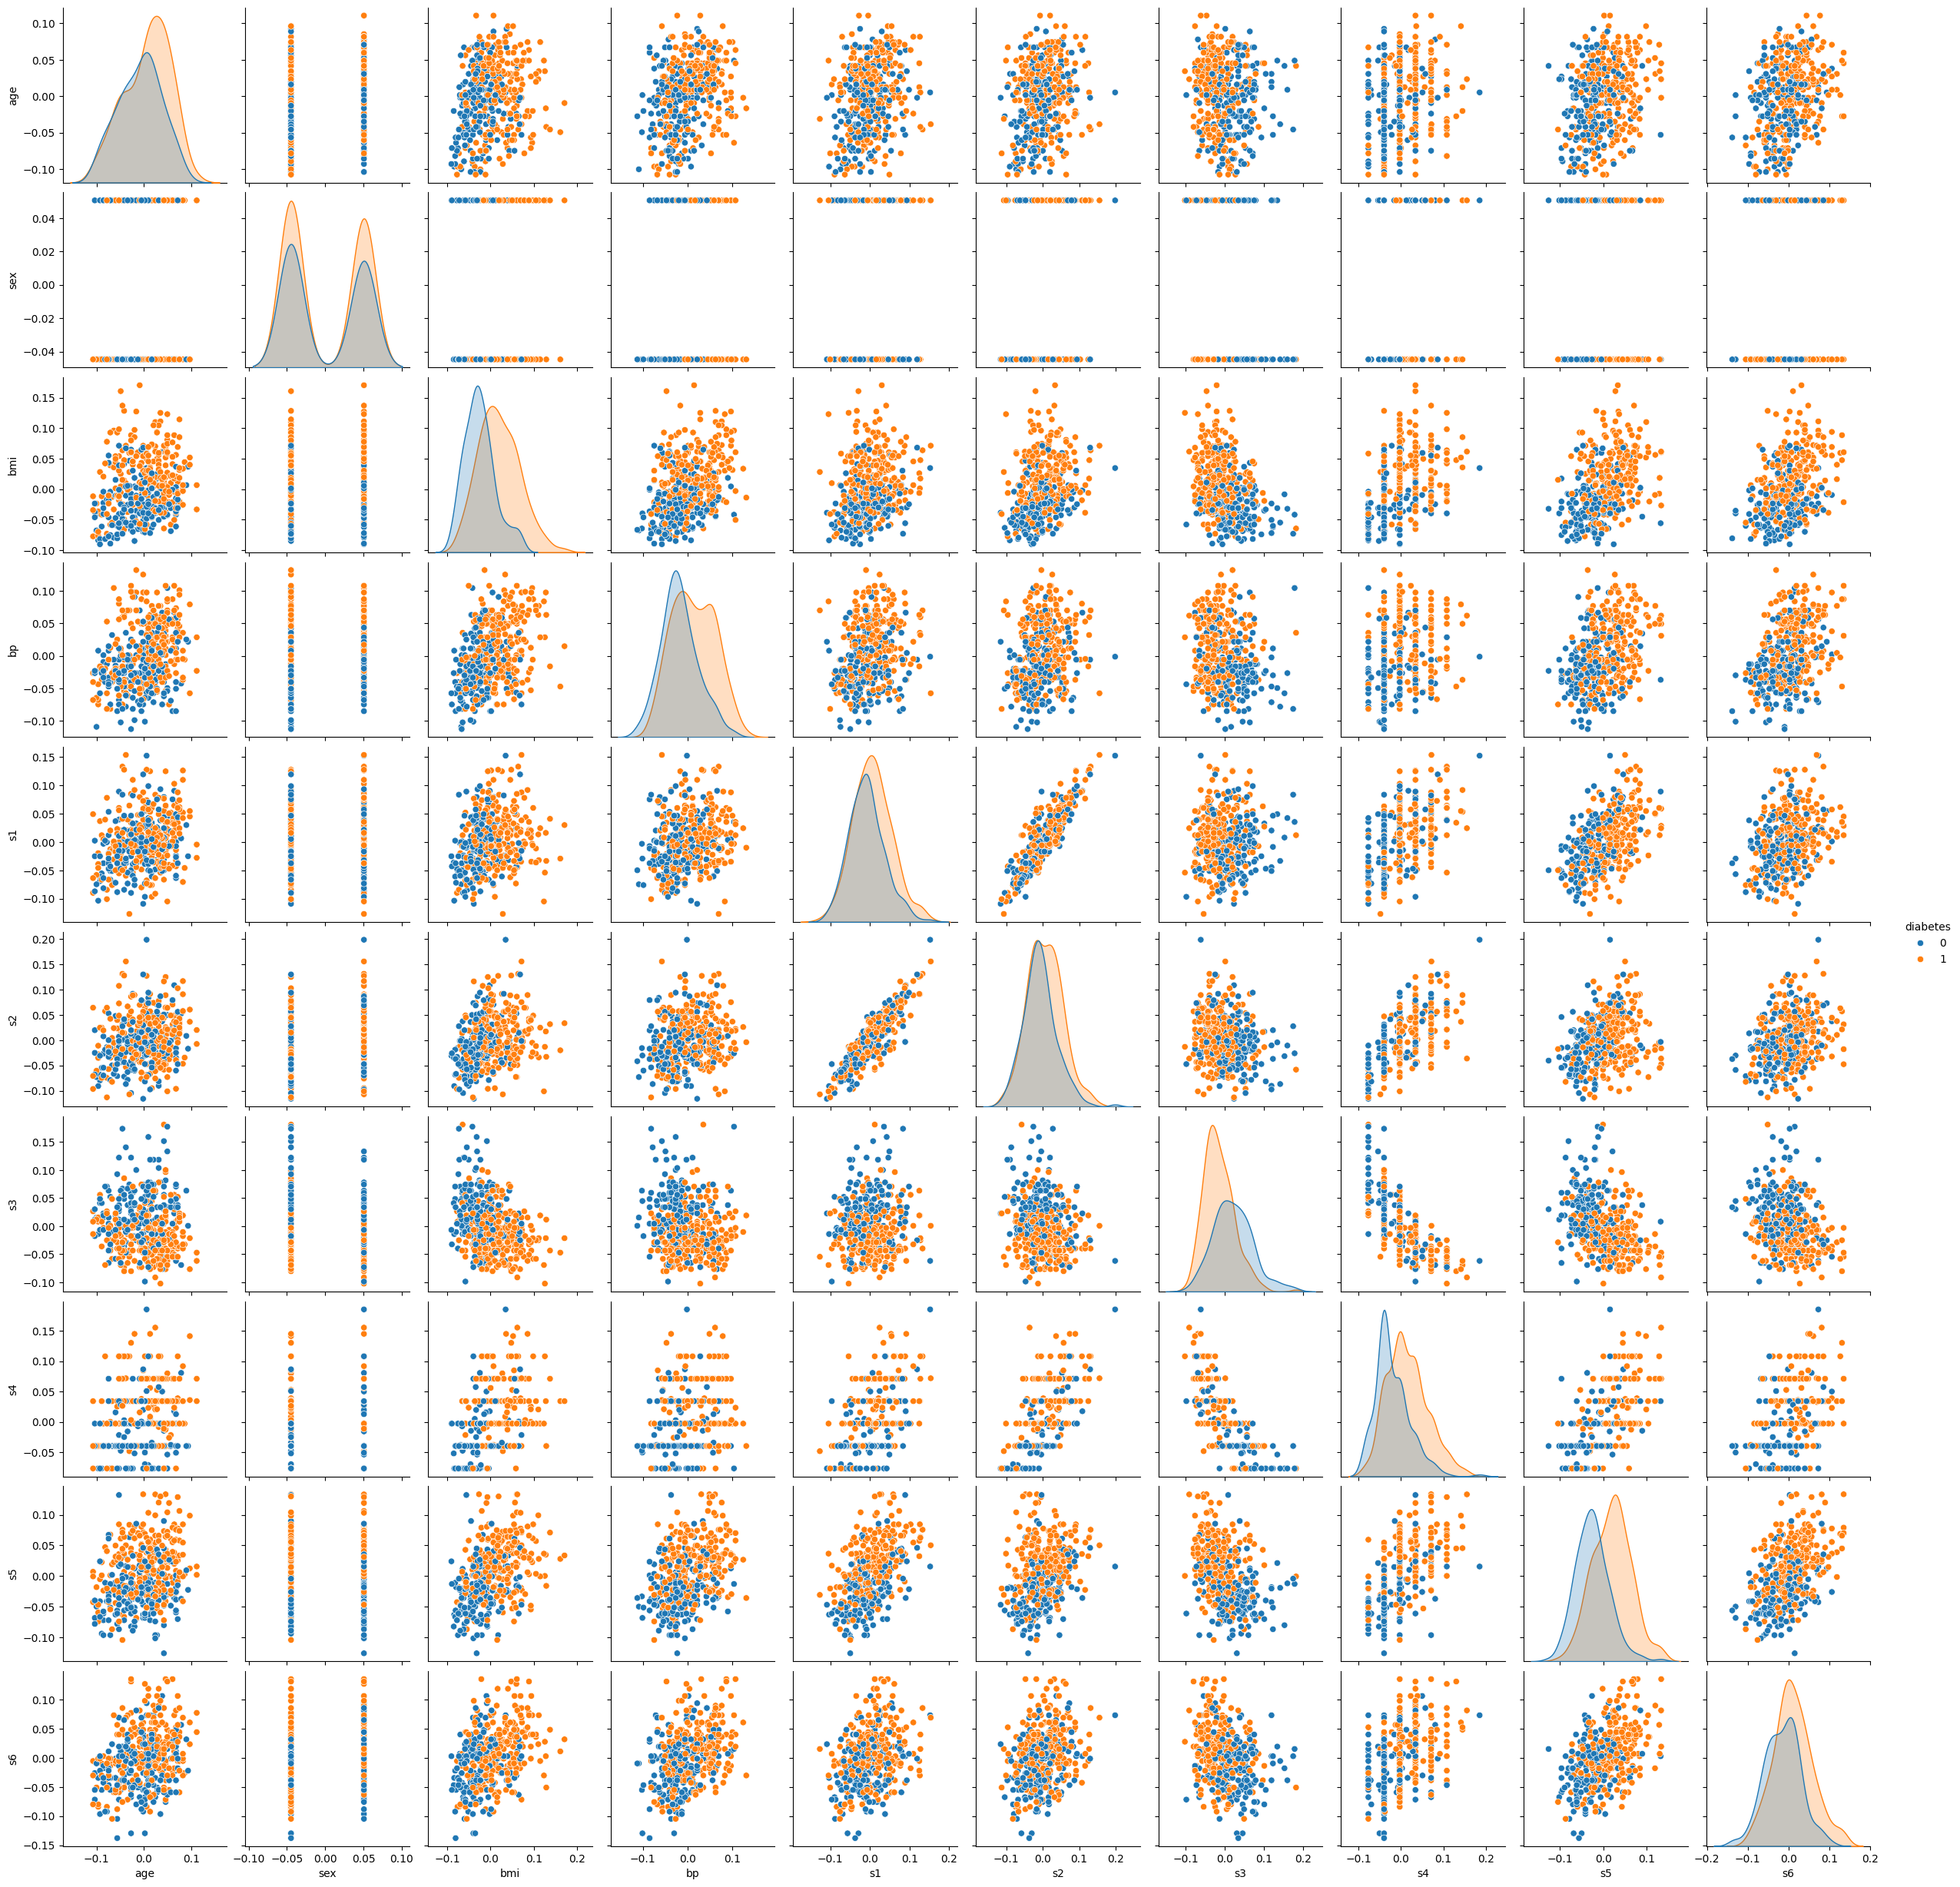

In [46]:
# sns.pairplot(df,hue='diabetes')

## THE ABOVE GRAPH SHOWING MOSTLY AS LINEARLY INCREASING

## MODEL TRAINING

In [47]:
x=df.drop('diabetes',axis=1)
y=df['diabetes']


In [48]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [49]:
model=SVC(kernel="rbf")
model.fit(xtrain,ytrain)

SVC()

In [50]:
ypred=model.predict(xtest)
ypred

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1])

## PERFORMANCE METRICS

In [51]:
print("confusion matric: ",confusion_matrix(ytest,model.predict(xtest)))
print("classification report: ",classification_report(ytest,model.predict(xtest)))



confusion matric:  [[43 19]
 [10 61]]
classification report:                precision    recall  f1-score   support

           0       0.81      0.69      0.75        62
           1       0.76      0.86      0.81        71

    accuracy                           0.78       133
   macro avg       0.79      0.78      0.78       133
weighted avg       0.79      0.78      0.78       133



## THIS MODEL IS GENERALISED MODEL

In [52]:
print("training_eff: ",model.score(xtrain,ytrain))
print("testing_eff: ",model.score(xtest,ytest))

training_eff:  0.8187702265372169
testing_eff:  0.7819548872180451


## NEW PREDICTION

In [53]:
new_Data=df.iloc[1:2,:-1]
model.predict(new_Data)

array([0])